In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/

/Users/arikreuter/Documents/PhD/CausalPriorFitting


In [8]:
# Reload modules to pick up changes
import importlib
import sys

# Remove cached modules
for module in list(sys.modules.keys()):
    if 'InterventionalPFN' in module or 'SimplePFN' in module:
        del sys.modules[module]

# Now import fresh (no 'src.' prefix since we're already in src/)
from src.models.InterventionalPFN_sklearn import InterventionalPFNSklearn
from src.models.GraphConditionedInterventionalPFN_sklearn import GraphConditionedInterventionalPFNSklearn
from src.models.SimplePFN_sklearn import SimplePFNSklearn
from sklearn.ensemble import RandomForestRegressor
from src.priordata_processing.BasicProcessing import BasicProcessing
import torch
from src.priors.causal_prior.noise_distributions.ResamplingDist import ResamplingDist

from src.priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from src.priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from src.priors.causal_prior.noise_distributions.MixedDist import MixedDist
from src.priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from src.priors.causal_prior.scm.SCM import SCM
from src.priors.causal_prior.noise_distributions.NormalDistribution import NormalDistribution
from src.priors.causal_prior.mechanisms.LinearMechanism import LinearMechanism
import numpy as np


In [4]:
config_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/configs/five_nodes_lingaus_ultimate_gcn_and_soft_attention.yaml"
checkpoint_path = "/Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16676647.0/step_50000.pt"

graphintpfn = GraphConditionedInterventionalPFNSklearn(
    config_path=config_path,
    checkpoint_path=checkpoint_path,
    verbose=True,  # Enable verbose mode to see diagnostic messages
)
graphintpfn.load()


# Processor should match the config: 50 features (excluding target, including intervention column)
processor = BasicProcessing(
    n_features=3,
    max_n_features=3,
    n_train_samples = 500,
    max_n_train_samples=500,
    n_test_samples=500,
    max_n_test_samples=500,
    dropout_prob=0.0,
    target_feature = 1,
    intervened_feature=0,
    feature_standardize= True,
    shuffle_features=False,
    shuffle_samples=False,
    feature_negative_one_one_scaling=  False,
    target_negative_one_one_scaling= True,
    remove_outliers= True,
    outlier_quantile= 0.99,
    yeo_johnson= False
)



[GraphConditionedInterventionalPFNSklearn] Loading model...
  Config: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/configs/five_nodes_lingaus_ultimate_gcn_and_soft_attention.yaml
  Checkpoint: /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16676647.0/step_50000.pt
  BarDistribution enabled: 1000 bars, output_dim=1004
  Graph conditioning mode: ultimate_gcn_and_hard_attention
  Building model with 3 features...
  Creating UltimateGraphConditionedInterventionalPFN
    use_attention_masking: True
    use_gcn: True
    use_adaln: True
    use_soft_attention_bias: False
  Loading checkpoint from /Users/arikreuter/Documents/PhD/CausalPriorFitting/experiments/GraphConditioning/checkpoints/simple_pfn_16676647.0/step_50000.pt...
  BarDistribution state loaded from checkpoint
    centers shape: torch.Size([1000])
    edges shape: torch.Size([1001])
  Checkpoint loaded successfully
  Model loaded with 11,

In [18]:
def plot_data_splits(X, T, Y, title="Data Split", figsize=(15, 12)):
    """
    Create pairwise scatterplots with marginal histograms for X, T, Y data.
    
    Parameters
    ----------
    X : ndarray
        Covariates array of shape (n_samples, n_features)
    T : ndarray
        Treatment/intervention values of shape (n_samples, 1) or (n_samples,)
    Y : ndarray
        Target values of shape (n_samples, 1) or (n_samples,)
    title : str, optional
        Overall title for the plots (default: "Data Split")
    figsize : tuple, optional
        Figure size (default: (15, 12))
    """
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    
    # Flatten arrays if needed
    T_flat = T.flatten() if len(T.shape) > 1 else T
    Y_flat = Y.flatten() if len(Y.shape) > 1 else Y
    
    # Determine number of features in X
    if len(X.shape) == 1:
        X = X.reshape(-1, 1)
    n_features = X.shape[1]
    
    # Create combined data matrix: [X features, T, Y]
    all_data = []
    var_names = []
    
    for i in range(n_features):
        X_i = X[:, i].flatten() if len(X[:, i].shape) > 1 else X[:, i]
        all_data.append(X_i)
        var_names.append(f'X_{i}')
    all_data.append(T_flat)
    var_names.append('T')
    all_data.append(Y_flat)
    var_names.append('Y')
    
    n_vars = len(all_data)
    
    # Create figure with GridSpec for corner plot style
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(n_vars, n_vars, figure=fig, hspace=0.05, wspace=0.05)
    
    axes = []
    for i in range(n_vars):
        row_axes = []
        for j in range(n_vars):
            if j <= i:
                ax = fig.add_subplot(gs[i, j])
                row_axes.append(ax)
            else:
                row_axes.append(None)
        axes.append(row_axes)
    
    # Fill in the plots
    for i in range(n_vars):
        for j in range(n_vars):
            if j > i:
                continue
                
            ax = axes[i][j]
            
            if i == j:
                # Diagonal: histogram
                ax.hist(all_data[i], bins=30, alpha=0.7, edgecolor='black')
                ax.set_ylabel('Frequency', fontsize=9)
                if i == n_vars - 1:
                    ax.set_xlabel(var_names[i], fontsize=10, fontweight='bold')
                else:
                    ax.set_xticklabels([])
            else:
                # Off-diagonal: scatter plot
                ax.scatter(all_data[j], all_data[i], alpha=0.5, s=10)
                ax.grid(True, alpha=0.3)
                
                # Labels
                if j == 0:
                    ax.set_ylabel(var_names[i], fontsize=10, fontweight='bold')
                else:
                    ax.set_yticklabels([])
                    
                if i == n_vars - 1:
                    ax.set_xlabel(var_names[j], fontsize=10, fontweight='bold')
                else:
                    ax.set_xticklabels([])
            
            # Adjust tick label sizes
            ax.tick_params(axis='both', which='major', labelsize=8)
    
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    plt.show()

In [ ]:
def generate_interventional_data(
    num_nodes,
    edge_list,
    mechanisms,
    processor,
    intervention_node=0,
    number_train_samples=500,
    number_test_samples=500,
    seed=None,
    draw_graph=False,
    plot_data=False
):
    """
    Generate observational and interventional data from a synthetic SCM.
    
    Parameters
    ----------
    num_nodes : int
        Number of nodes in the causal graph
    edge_list : list of tuples
        List of directed edges (parent, child)
    mechanisms : dict
        Dictionary mapping node indices to mechanism objects
    processor : BasicProcessing
        Data processor for standardization and formatting
    intervention_node : int, optional
        Node to intervene on (default: 0)
    number_train_samples : int, optional
        Number of training (observational) samples (default: 500)
    number_test_samples : int, optional
        Number of test (interventional) samples (default: 500)
    seed : int, optional
        Random seed for graph generation (default: None)
    draw_graph : bool, optional
        If True, draw the causal graph before and after intervention (default: False)
    plot_data : bool, optional
        If True, create pairwise scatterplots of the processed data (default: False)
    
    Returns
    -------
    X_train : ndarray
        Processed training covariates
    T_train : ndarray
        Processed training treatment/intervention values
    Y_train : ndarray
        Processed training targets
    X_test : ndarray
        Processed test covariates
    T_test : ndarray
        Processed test treatment/intervention values
    Y_test : ndarray
        Processed test targets
    scm : SCM
        The structural causal model object
    causal_dag : CausalDAG
        The causal DAG object
    """
    # Create graph
    graph_sampler = GraphSampler(seed=seed)
    graph = graph_sampler.sample_dag(num_nodes=num_nodes, p=0.0)  # Start with empty graph
    
    # Clear any edges and add specified edges
    graph.clear_edges()
    graph.add_edges_from(edge_list)
    
    # Create causal DAG
    causal_dag = CausalDAG(g=graph, check_acyclic=True)
    
    # Draw original graph if requested
    if draw_graph:
        print("Original Causal Graph (Observational):")
        causal_dag.draw()
    
    # Setup noise distributions
    exogenous_variables = causal_dag.exogenous_variables()
    endogenous_variables = causal_dag.endogenous_variables()
    
    exo_noise = {}
    for var in exogenous_variables:
        exo_noise[var] = NormalDistribution(mean=0, std=1)
    
    endo_noise = {}
    for var in endogenous_variables:
        endo_noise[var] = NormalDistribution(mean=0, std=1)
    
    # Create SCM
    scm = SCM(
        dag=causal_dag,
        mechanisms=mechanisms,
        exogenous_noise=exo_noise,
        endogenous_noise=endo_noise,
        use_exogenous_mechanisms=False
    )
    
    # Sample observational training data
    scm.sample_exogenous(num_samples=number_train_samples)
    scm.sample_endogenous(num_samples=number_train_samples)
    obs0_raw = scm.propagate(num_samples=number_train_samples)
    
    # Reshape from (N,) to (N,1) for BasicProcessing compatibility
    obs0 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in obs0_raw.items()}
    
    # Sample fresh observational data for test set marginal
    scm.sample_exogenous(num_samples=number_test_samples)
    scm.sample_endogenous(num_samples=number_test_samples)
    obs1_raw = scm.propagate(num_samples=number_test_samples)
    
    # Collect observational samples for the intervention node (marginal)
    intervention_samples = obs1_raw[intervention_node]
    
    # Create resampling distribution over observational marginal
    interventional_dist = ResamplingDist(intervention_samples)
    
    # Perform intervention
    scm.intervene(node=intervention_node)
    
    # Draw intervened graph if requested
    if draw_graph:
        print(f"\nIntervened Causal Graph (do(Node {intervention_node})):")
        scm.dag.draw()
    
    # Replace the noise distribution for the intervened node
    if intervention_node in scm.dag.endogenous_variables():
        scm.endogenous_noise[intervention_node] = interventional_dist
    if intervention_node in scm.dag.exogenous_variables():
        scm.exogenous_noise[intervention_node] = interventional_dist
    
    # Sample new noise for interventional scenario
    scm.sample_exogenous(num_samples=number_test_samples)
    scm.sample_endogenous(num_samples=number_test_samples)
    
    # Generate interventional data
    interv1_raw = scm.propagate(num_samples=number_test_samples)
    
    # Reshape from (N,) to (N,1) for BasicProcessing compatibility
    interv1 = {k: v.reshape(-1, 1) if v.dim() == 1 else v for k, v in interv1_raw.items()}
    
    # Process the data using the provided processor
    X_train, T_train, Y_train, X_test, T_test, Y_test = processor.process_from_splits(obs0, interv1)
    
    # Plot data if requested
    if plot_data:
        plot_data_splits(X_train, T_train, Y_train, 
                        title=f"Training Data (Observational, n={number_train_samples})")
        plot_data_splits(X_test, T_test, Y_test, 
                        title=f"Test Data (Interventional do(Node {intervention_node}), n={number_test_samples})")
        
    adjacency_matrix = scm.get_adjacency_matrix(node_order= 
    
    return X_train, T_train, Y_train, X_test, T_test, Y_test, scm, causal_dag

Original Causal Graph (Observational):


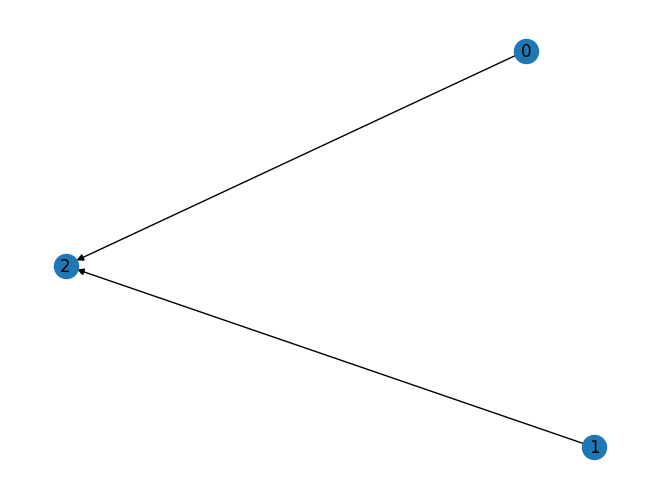


Intervened Causal Graph (do(Node 0)):


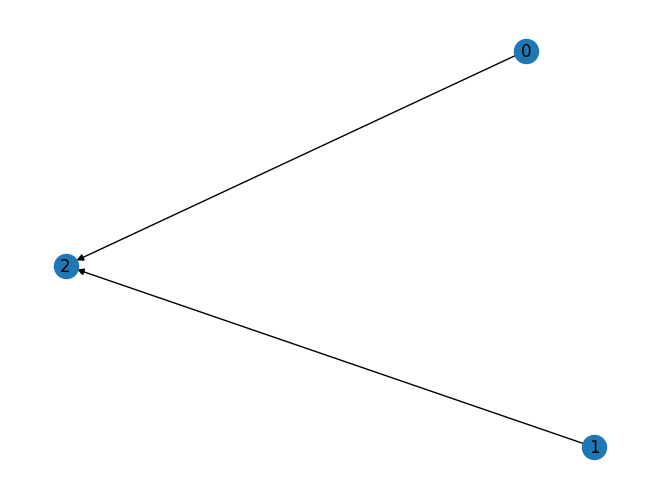

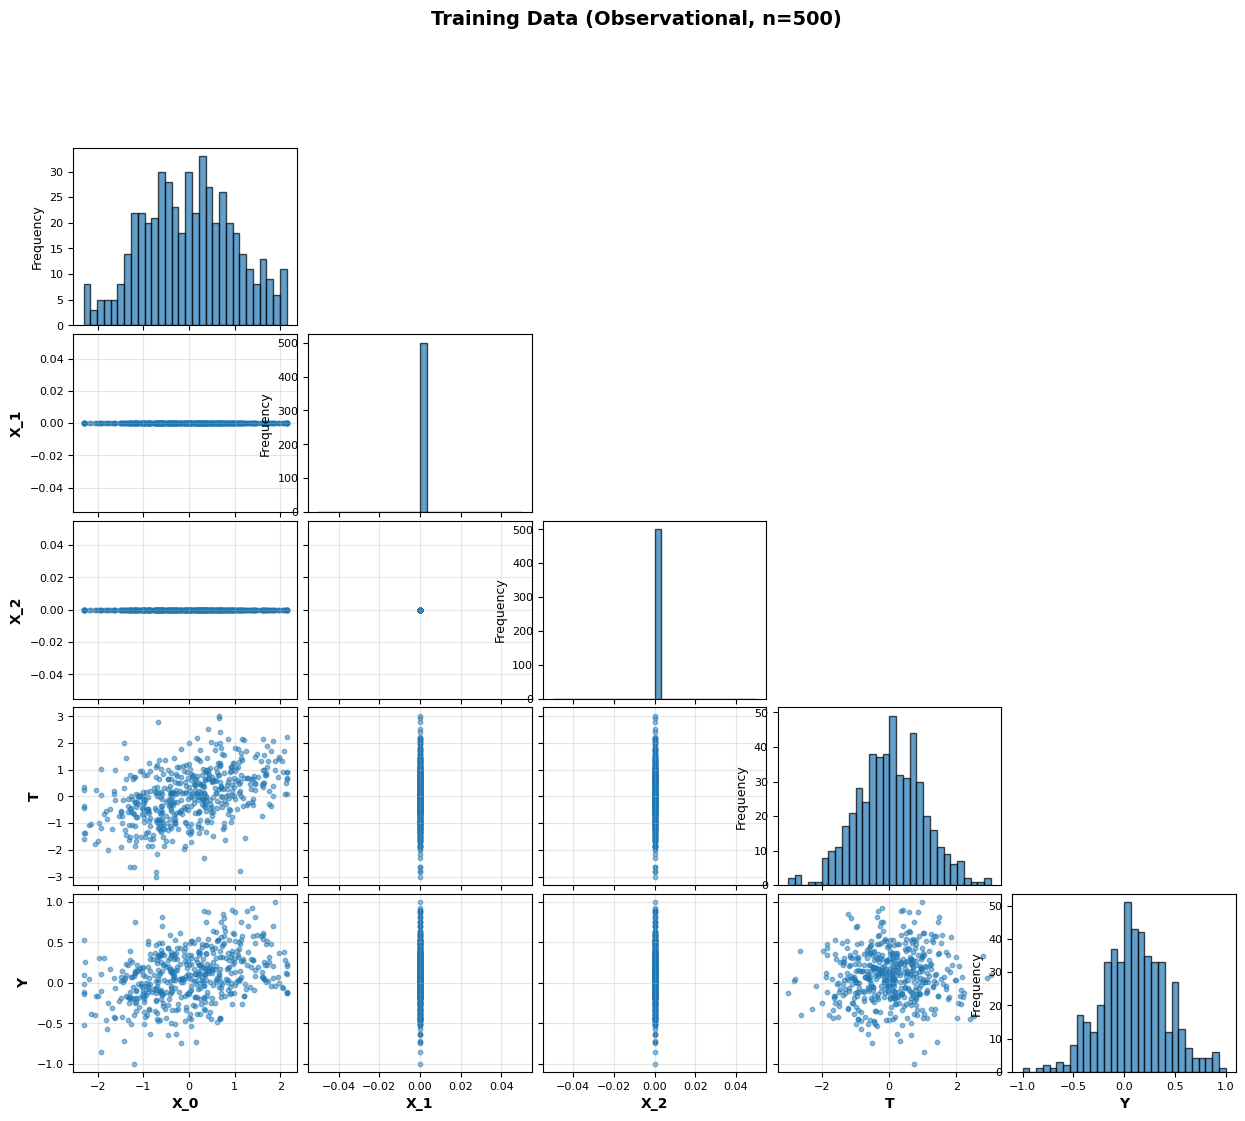

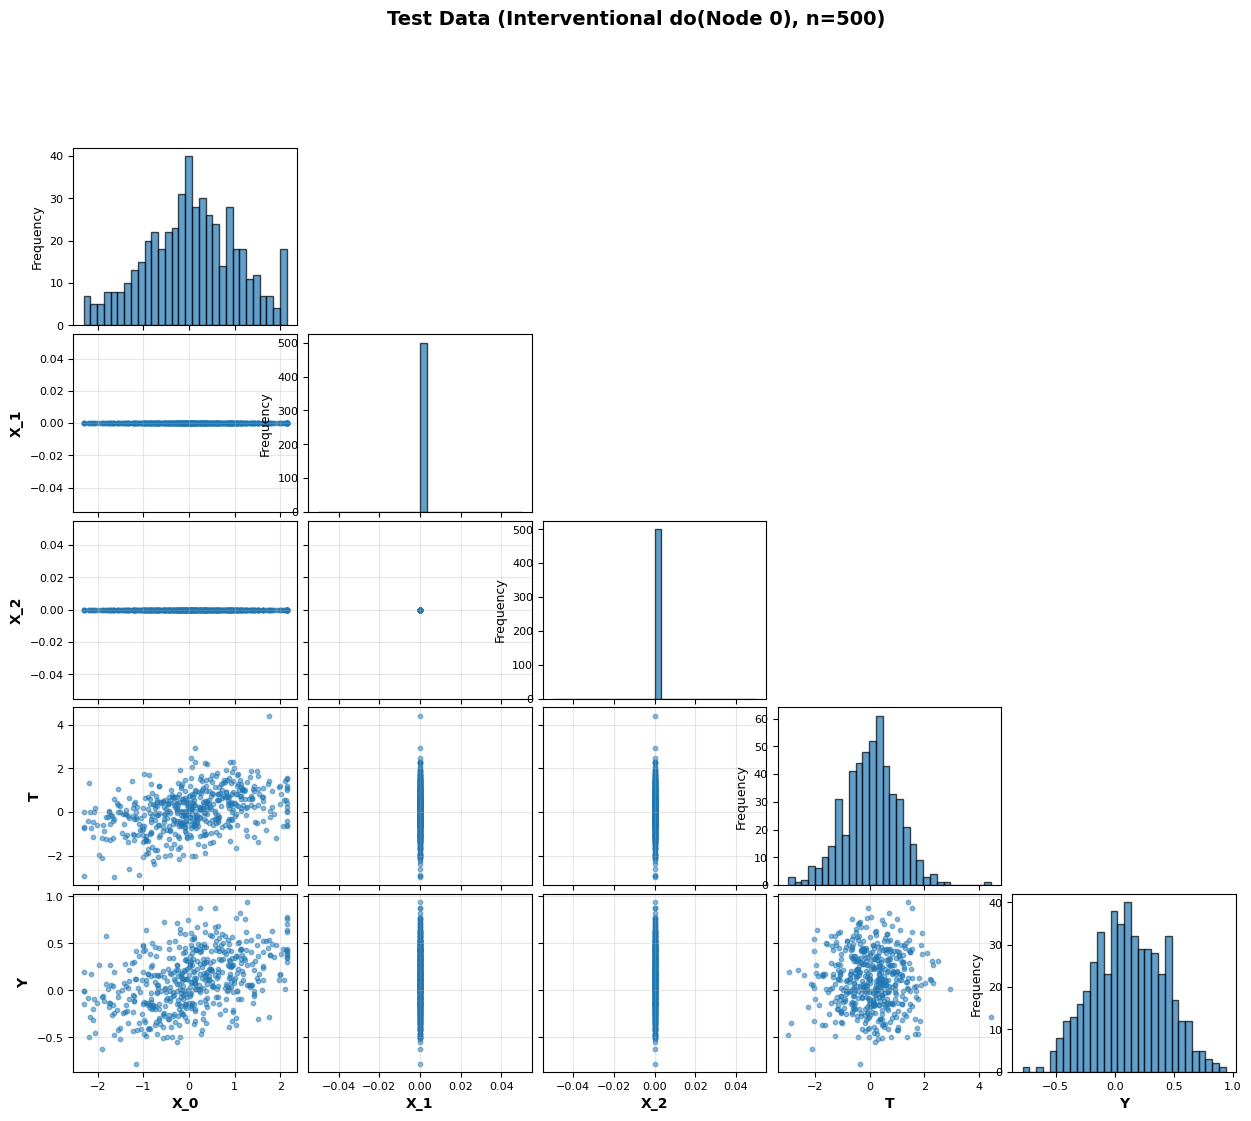

In [21]:
# Define the graph structure
NUM_NODES = 3
SEED = 42

edges = [(1, 2), (0, 2)]

# Define mechanisms
mechanisms = {}
mechanisms[2] = LinearMechanism(
    input_dim=2,
    weights=[1.0, 1.0],
    nonlinearity=lambda x: torch.tanh(x),
    standardize=True
)

# Generate and process data using the function
X_train, T_train, Y_train, X_test, T_test, Y_test, scm, causal_dag = generate_interventional_data(
    num_nodes=NUM_NODES,
    edge_list=edges,
    mechanisms=mechanisms,
    processor=processor,
    intervention_node=0,
    number_train_samples=500,
    number_test_samples=500,
    seed=SEED,
    draw_graph=True,   # Set to True to visualize graphs before and after intervention
    plot_data=True     # Set to True to visualize the processed data splits
)